# Analise Exploratoria - CoinGecko Data Warehouse

Este notebook realiza a **Analise Exploratoria de Dados (EDA)** dos dados
extraidos da API CoinGecko e carregados no Data Warehouse PostgreSQL.

### Tabelas de Staging
| Tabela | Endpoint | Descricao |
|---|---|---|
| `staging.coingecko_coins` | `/coins/markets` | Preco, market cap, volume das top moedas |
| `staging.coingecko_list` | `/coins/list` | Lista completa de moedas (id, symbol, name) |
| `staging.coingecko_global` | `/global` | Estatisticas globais do mercado crypto |
| `staging.coingecko_trending` | `/search/trending` | Moedas em alta no momento |

### Estrutura do Notebook
1. Conexao com o banco de dados
2. Visao geral das tabelas
3. Analise de `coingecko_coins`
4. Analise de `coingecko_list`
5. Analise de `coingecko_global`
6. Analise de `coingecko_trending`
7. Historico de jobs ETL
8. Fechamento

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Conexao com o Banco de Dados

In [25]:
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "data_warehouse"
DB_USER = "postgres"
DB_PASS = "postgres"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("Conexao OK!" if result.fetchone() else "Erro na conexao")

Conexao OK!


## 2. Visao Geral das Tabelas

In [26]:
tables = {
    'coingecko_coins': 'staging.coingecko_coins',
    'coingecko_list': 'staging.coingecko_list',
    'coingecko_global': 'staging.coingecko_global',
    'coingecko_trending': 'staging.coingecko_trending',
}

print('Contagem de registros por tabela:')
for name, table in tables.items():
    count = pd.read_sql(f'SELECT COUNT(*) as cnt FROM {table}', engine).iloc[0, 0]
    print(f'  {name}: {count}')

Contagem de registros por tabela:
  coingecko_coins: 2000
  coingecko_list: 19790
  coingecko_global: 1
  coingecko_trending: 15


## 3. Analise de `coingecko_coins`

Dados de preco, market cap, volume e metadados das principais criptomoedas.

In [27]:
query = """
SELECT DISTINCT ON (coin_id)
    coin_id, symbol, name, current_price, market_cap, market_cap_rank,
    total_volume, high_24h, low_24h, price_change_24h,
    price_change_percentage_24h, market_cap_change_percentage_24h,
    circulating_supply, total_supply, max_supply,
    ath, ath_change_percentage, ath_date,
    atl, atl_change_percentage, atl_date,
    last_updated
FROM staging.coingecko_coins
ORDER BY coin_id, last_updated DESC
"""

df = pd.read_sql(query, engine)
print(f'Moedas unicas: {len(df)}')
df.head(10)

Moedas unicas: 103


,coin_id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,last_updated
0,aave,aave,Aave,124.96,1927804570,46,176942206,123.51,120.57,3.13,2.57,2.57,15427562.52,16000000.00,16000000.00,661.69,-81.12,2021-05-18 13:19:59+00:00,26.02,380.18,2020-11-05 01:20:11+00:00,2026-09-11 12:56:20+00:00
1,aerodrome-finance,aero,Aerodrome Finance,0.57,562721757,98,31520992,0.56,0.54,0.03,5.13,5.14,988997985.02,1978450301.48,0.00,2.32,-75.44,2024-12-07 06:00:38+00:00,0.00,3057303.85,2023-10-16 17:23:50+00:00,2026-09-11 12:56:20+00:00
2,algorand,algo,Algorand,0.09,827062991,83,44836348,0.10,0.09,-0.01,-5.36,-5.36,9040075710.16,9040214132.26,10000000000.00,3.56,-97.43,2019-06-20 06:51:19+00:00,0.08,20.81,2026-07-29 20:10:10+00:00,2026-09-11 12:56:20+00:00
3,aptos,apt,Aptos,0.64,551092806,99,99537276,0.65,0.61,-0.00,-0.70,-0.49,858753826.65,1208503699.03,2100000000.00,19.92,-96.78,2023-01-26 06:25:17+00:00,0.51,25.35,2026-08-30 23:47:30+00:00,2026-09-10 21:35:10+00:00
4,arbitrum,arb,Arbitrum,0.14,960906734,77,205315283,0.15,0.14,-0.00,-2.65,-2.65,6678075931.00,10000000000.00,10000000000.00,2.39,-93.98,2024-01-12 04:29:59+00:00,0.07,104.16,2026-06-26 13:20:40+00:00,2026-09-11 12:56:20+00:00
5,aster-2,aster,Aster,0.70,1893842340,47,129124404,0.71,0.68,-0.00,-0.32,-0.32,2704071066.80,7803968119.65,8000000000.00,2.41,-70.92,2025-09-24 03:18:14+00:00,0.10,602.38,2025-09-17 04:05:36+00:00,2026-09-11 12:56:20+00:00
6,avalanche-2,avax,Avalanche,7.56,3347123537,30,257539749,7.66,7.30,-0.02,-0.26,2.22,442490359.07,469158789.16,720000000.00,144.96,-94.78,2021-11-21 06:18:56+00:00,2.80,170.05,2020-12-31 05:15:21+00:00,2026-09-11 12:56:20+00:00
7,beldex,bdx,Beldex,0.08,606612065,96,10596425,0.08,0.08,0.00,0.26,0.26,7870612963.64,9939553047.50,0.00,0.45,-82.90,2018-12-16 16:00:00+00:00,0.00,27907.64,2019-11-01 03:05:12+00:00,2026-09-11 12:56:20+00:00
8,bfusd,bfusd,BFUSD,1.00,1319302420,66,4733554,1.00,1.00,-0.00,-0.01,-0.01,1320000000.00,1320000000.00,0.00,1.01,-0.74,2025-10-10 13:40:40+00:00,1.00,0.25,2026-07-29 19:14:40+00:00,2026-09-11 12:56:20+00:00
9,binancecoin,bnb,BNB,722.62,96225434403,4,897901692,717.01,704.72,16.51,2.34,2.34,133161118.37,133161113.02,200000000.00,1369.99,-47.25,2025-10-13 00:41:24+00:00,0.04,1814731.49,2017-10-18 16:00:00+00:00,2026-09-11 12:56:20+00:00


In [28]:
print('Shape:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print(f'\nMemoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Shape: (103, 22)

Tipos de dados:
coin_id                                             str
symbol                                              str
name                                                str
current_price                                   float64
market_cap                                        int64
market_cap_rank                                   int64
total_volume                                      int64
high_24h                                        float64
low_24h                                         float64
price_change_24h                                float64
price_change_percentage_24h                     float64
market_cap_change_percentage_24h                float64
circulating_supply                              float64
total_supply                                    float64
max_supply                                      float64
ath                                             float64
ath_change_percentage                           float64
ath_date      

In [29]:
df[['current_price', 'market_cap', 'total_volume', 'circulating_supply']].describe()

,current_price,market_cap,total_volume,circulating_supply
count,103.00,103.00,103.00,103.00
mean,902.81,26127358700.59,1412086478.00,18548984605141.41
std,7691.57,157643710837.83,6857227808.62,112701544377420.75
min,0.00,547713676.00,0.00,432502.17
25%,0.29,954414319.00,10264024.50,381339285.76
50%,1.00,1633139424.00,77189107.00,1382942040.16
75%,6.59,3865772918.50,223220204.50,9921253343.42
max,77919.00,1564839249386.00,59231205874.00,898232728634017.25


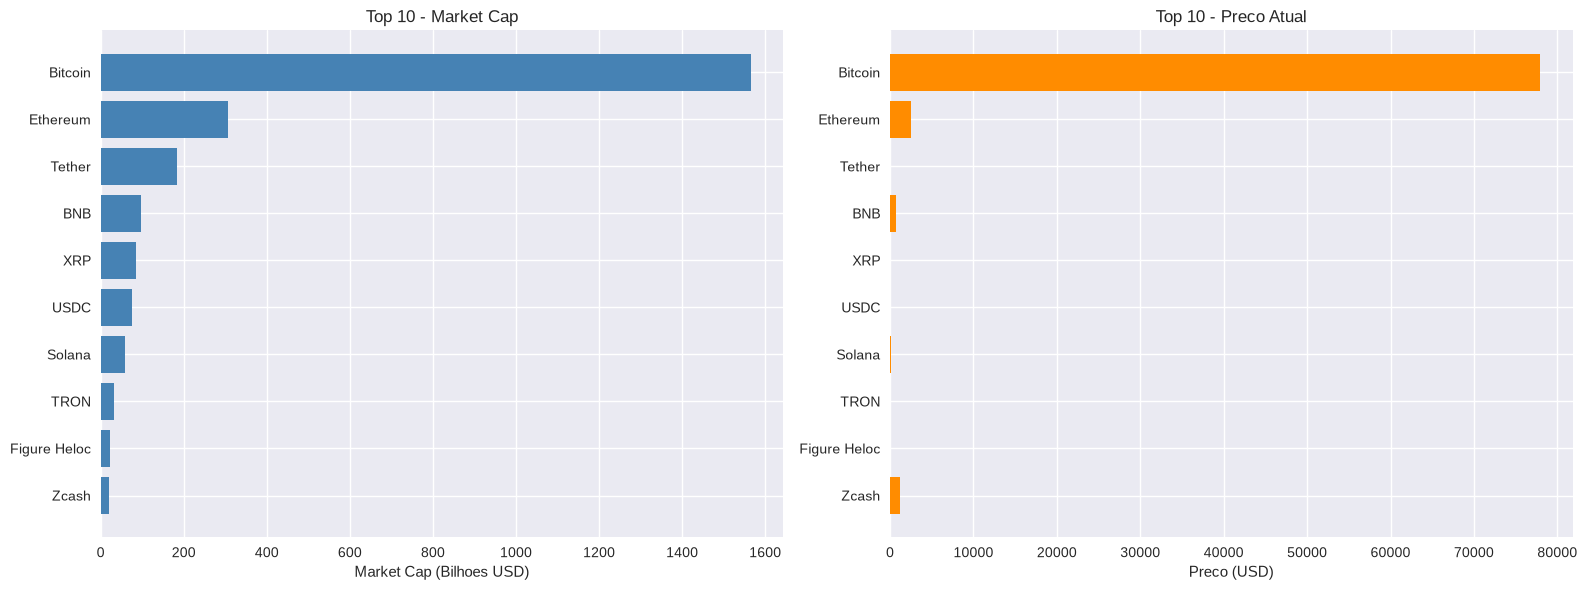

In [30]:
top10 = df.nsmallest(10, 'market_cap_rank')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['name'], top10['market_cap'] / 1e9, color='steelblue')
axes[0].set_xlabel('Market Cap (Bilhoes USD)')
axes[0].set_title('Top 10 - Market Cap')
axes[0].invert_yaxis()

axes[1].barh(top10['name'], top10['current_price'], color='darkorange')
axes[1].set_xlabel('Preco (USD)')
axes[1].set_title('Top 10 - Preco Atual')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

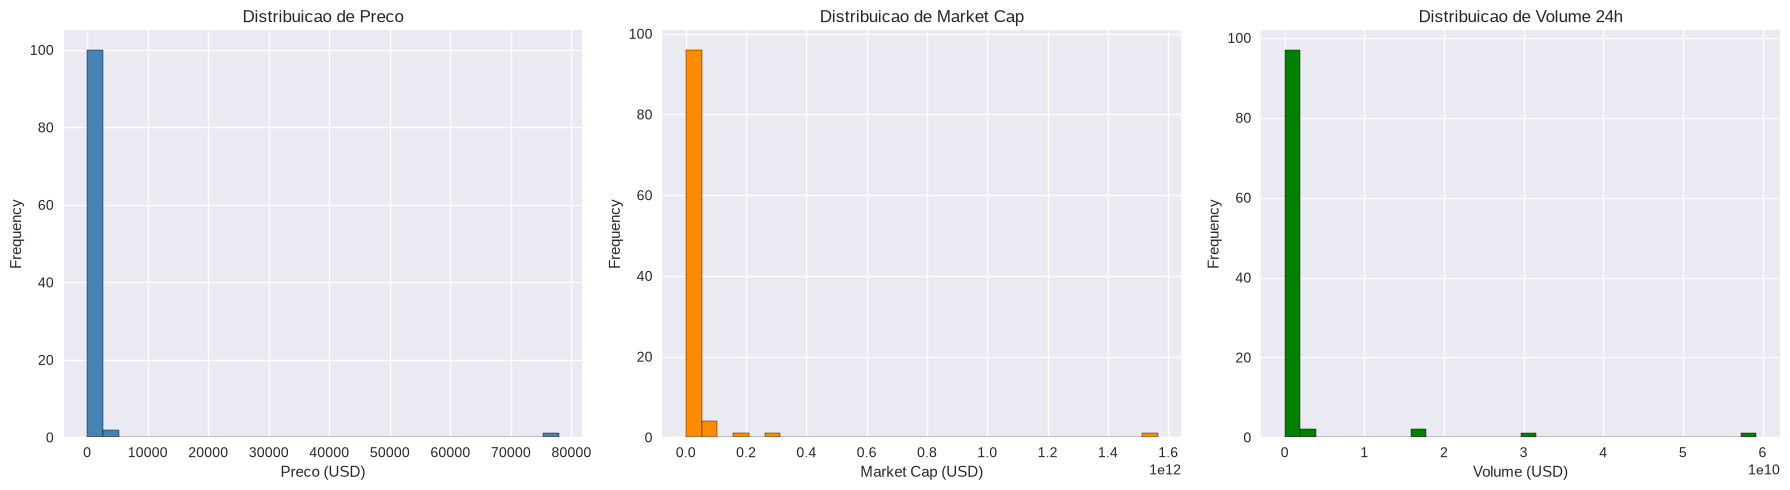

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['current_price'].plot(kind='hist', ax=axes[0], bins=30, edgecolor='black', color='steelblue')
axes[0].set_title('Distribuicao de Preco')
axes[0].set_xlabel('Preco (USD)')

df['market_cap'].plot(kind='hist', ax=axes[1], bins=30, edgecolor='black', color='darkorange')
axes[1].set_title('Distribuicao de Market Cap')
axes[1].set_xlabel('Market Cap (USD)')

df['total_volume'].plot(kind='hist', ax=axes[2], bins=30, edgecolor='black', color='green')
axes[2].set_title('Distribuicao de Volume 24h')
axes[2].set_xlabel('Volume (USD)')

plt.tight_layout()
plt.show()

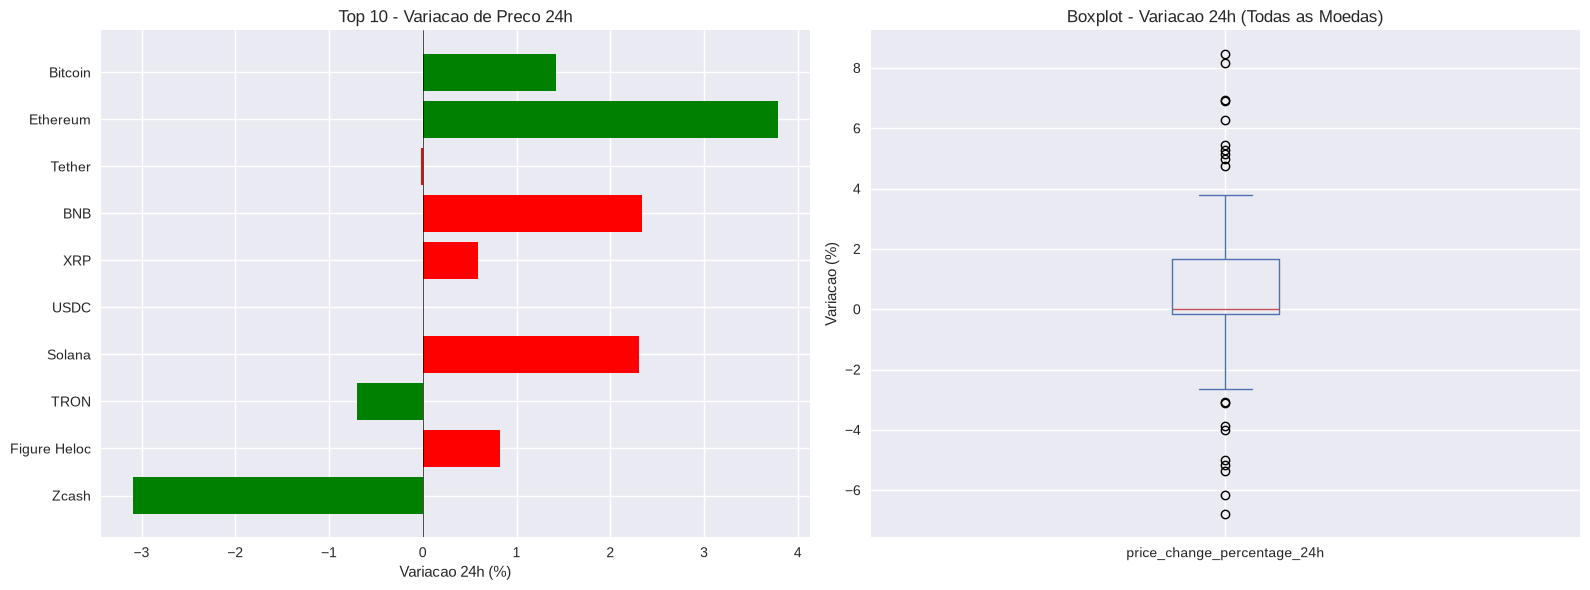

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green' if x >= 0 else 'red' for x in df['price_change_percentage_24h']]

axes[0].barh(top10['name'], top10['price_change_percentage_24h'], color=colors[:10])
axes[0].set_xlabel('Variacao 24h (%)')
axes[0].set_title('Top 10 - Variacao de Preco 24h')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].invert_yaxis()

df['price_change_percentage_24h'].plot(kind='box', ax=axes[1], vert=True)
axes[1].set_title('Boxplot - Variacao 24h (Todas as Moedas)')
axes[1].set_ylabel('Variacao (%)')

plt.tight_layout()
plt.show()

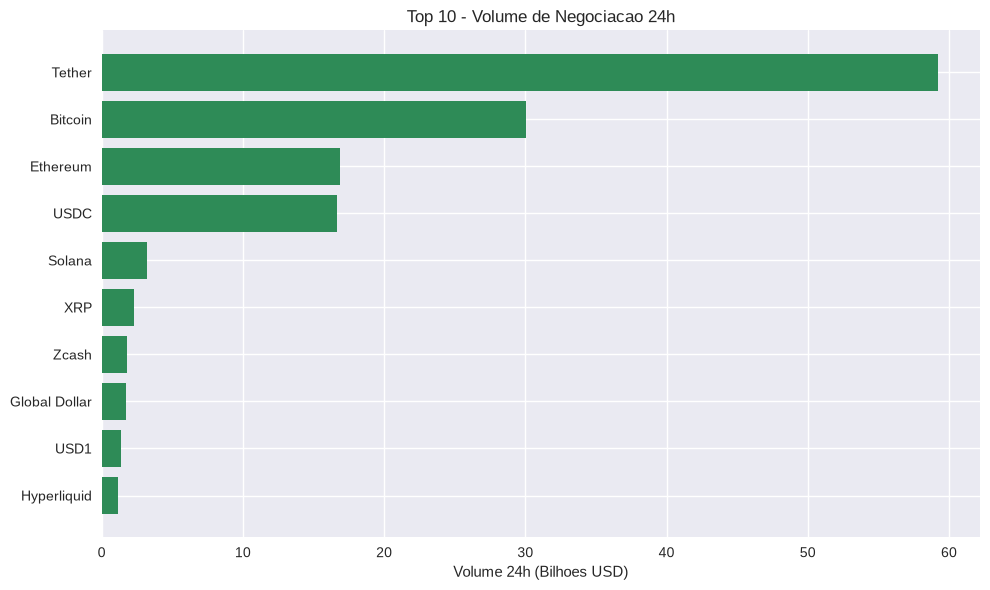

In [33]:
top10_vol = df.nlargest(10, 'total_volume')

plt.figure(figsize=(10, 6))
plt.barh(top10_vol['name'], top10_vol['total_volume'] / 1e9, color='seagreen')
plt.xlabel('Volume 24h (Bilhoes USD)')
plt.title('Top 10 - Volume de Negociacao 24h')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

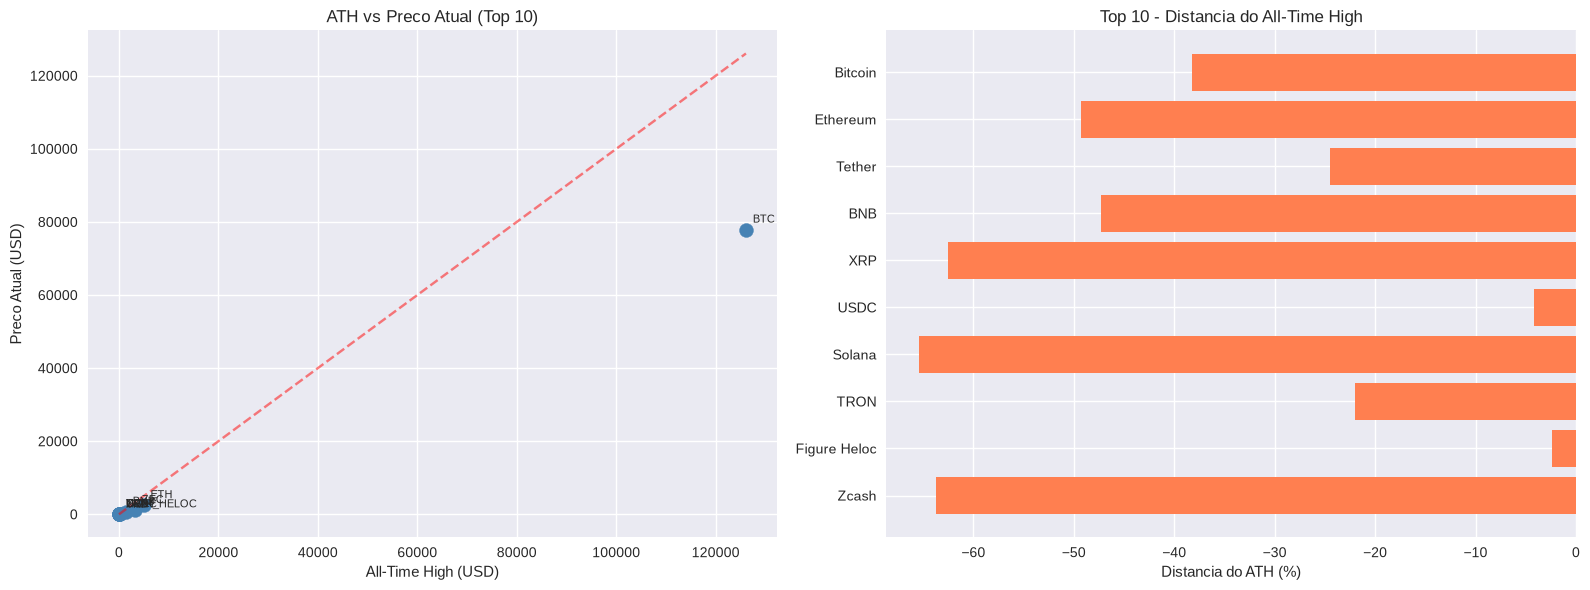

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(top10['ath'], top10['current_price'], color='steelblue', s=100)
axes[0].plot([0, top10['ath'].max()], [0, top10['ath'].max()], 'r--', alpha=0.5)
axes[0].set_xlabel('All-Time High (USD)')
axes[0].set_ylabel('Preco Atual (USD)')
axes[0].set_title('ATH vs Preco Atual (Top 10)')

for _, row in top10.iterrows():
    axes[0].annotate(row['symbol'].upper(), (row['ath'], row['current_price']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[1].barh(top10['name'], top10['ath_change_percentage'], color='coral')
axes[1].set_xlabel('Distancia do ATH (%)')
axes[1].set_title('Top 10 - Distancia do All-Time High')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

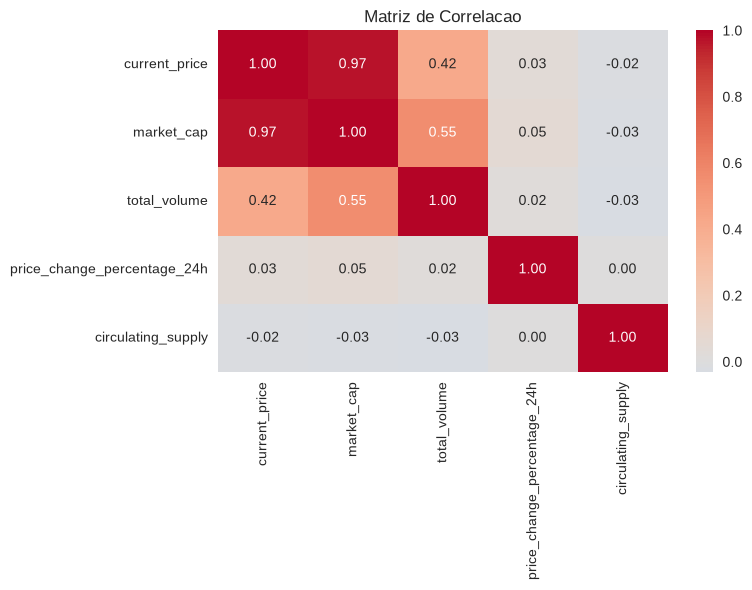

In [35]:
corr_cols = ['current_price', 'market_cap', 'total_volume',
             'price_change_percentage_24h', 'circulating_supply']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlacao')
plt.tight_layout()
plt.show()

## 4. Analise de `coingecko_list`

Lista completa de todas as moedas disponiveis na CoinGecko (coin_id, symbol, name).

In [36]:
df_list = pd.read_sql("SELECT * FROM staging.coingecko_list ORDER BY coin_id", engine)
print(f'Total de moedas: {len(df_list)}')
print(f'Moedas unicas (por coin_id): {df_list["coin_id"].nunique()}')
df_list.head(10)

Total de moedas: 19790
Moedas unicas (por coin_id): 19790


,id,coin_id,symbol,name,_extracted_at,_loaded_at
0,1,_,gib,༼ つ ◕_◕ ༽つ,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
1,2,000-capital,000,000 Capital,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
2,3,01111010011110000110001001110100-token,01111010011110000110001001110100,01111010011110000110001001110100,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
3,4,01112131415161718192021222324252-token,1234567891,01112131415161718192021222324252,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
4,5,01-token,01,01,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
5,6,035hanpanaitte,035hp!,035HanPanaitte!,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
6,7,0chain,zcn,Zus,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
7,8,0g-wrapped-wbtc-0g,wbtc,0G Wrapped WBTC (0G),2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
8,9,0x,zrx,0x Protocol,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00
9,10,0x0-ai-ai-smart-contract,0x0,0x0,2026-09-10 21:20:42.468305+00:00,2026-09-10 21:20:44.939391+00:00


In [37]:
df_list['symbol_len'] = df_list['symbol'].str.len()
print('Distribuicao do tamanho dos symbols:')
print(df_list['symbol_len'].value_counts().sort_index())

Distribuicao do tamanho dos symbols:
symbol_len
0        3
1      104
2      545
3     3987
4     6340
5     3963
6     2384
7     1030
8      684
9      400
10     202
11      55
12      31
13      18
14      16
15      12
16       4
17       2
18       2
19       1
21       1
22       1
23       1
24       1
27       1
32       1
38       1
Name: count, dtype: int64


## 5. Analise de `coingecko_global`

Estatisticas globais do mercado de criptomoedas (market cap total, volume, dominancia).

In [38]:
df_global = pd.read_sql("SELECT * FROM staging.coingecko_global", engine)
print(f'Registros: {len(df_global)}')
df_global

Registros: 1


,id,active_cryptocurrencies,markets,total_market_cap,total_volume,market_cap_percentage,market_cap_change_percentage_24h_usd,volume_change_percentage_24h_usd,updated_at,_extracted_at,_loaded_at
0,1,19791,1496,"{'aed': 9716418575254.2, 'ars': 40017565524450...","{'aed': 335096098294.48395, 'ars': 13801103736...","{'bnb': 3.585741190266303, 'btc': 58.482080705...",-4.10,-0.49,2026-09-10 21:32:53+00:00,2026-09-10 21:38:12.987293+00:00,2026-09-10 21:38:15.226236+00:00


In [39]:
import json

if len(df_global) > 0:
    row = df_global.iloc[0]
    print(f'Criptomoedas ativas: {row["active_cryptocurrencies"]}')
    print(f'Mercados: {row["markets"]}')
    print(f'Atualizado em: {row["updated_at"]}')

    if row['total_market_cap']:
        mc = json.loads(row['total_market_cap']) if isinstance(row['total_market_cap'], str) else row['total_market_cap']
        print(f'\nMarket Cap Total (USD): ${mc.get("usd", 0):,.0f}')
        print(f'Market Cap Total (BTC): {mc.get("btc", 0):,.0f}')

    if row['market_cap_percentage']:
        pct = json.loads(row['market_cap_percentage']) if isinstance(row['market_cap_percentage'], str) else row['market_cap_percentage']
        print(f'\nDominancia BTC: {pct.get("btc", 0):.2f}%')
        print(f'Dominancia ETH: {pct.get("eth", 0):.2f}%')

    print(f'\nVariacao market cap 24h: {row["market_cap_change_percentage_24h_usd"]:.2f}%')
else:
    print('Tabela vazia')

Criptomoedas ativas: 19791
Mercados: 1496
Atualizado em: 2026-09-10 21:32:53+00:00

Market Cap Total (USD): $2,645,435,099,037
Market Cap Total (BTC): 34,332,229

Dominancia BTC: 58.48%
Dominancia ETH: 11.33%

Variacao market cap 24h: -4.10%


## 6. Analise de `coingecko_trending`

Moedas que estao em alta no momento (trending no CoinGecko).

In [40]:
df_trend = pd.read_sql(
    "SELECT coin_id, name, symbol, market_cap_rank, score FROM staging.coingecko_trending ORDER BY market_cap_rank",
    engine
)
print(f'Moedas trending: {len(df_trend)}')
df_trend

Moedas trending: 15


,coin_id,name,symbol,market_cap_rank,score
0,1,Bitcoin,BTC,1,11
1,44,XRP,XRP,5,8
2,4128,Solana,SOL,7,10
3,486,Zcash,ZEC,10,6
4,10365,NEAR Protocol,NEAR,31,9
5,26580,Ondo,ONDO,51,14
6,54023,Venice Token,VVV,69,7
7,12882,Injective,INJ,97,13
8,52622,Pudgy Penguins,PENGU,111,5
9,102174571,Pons,PONS,118,2


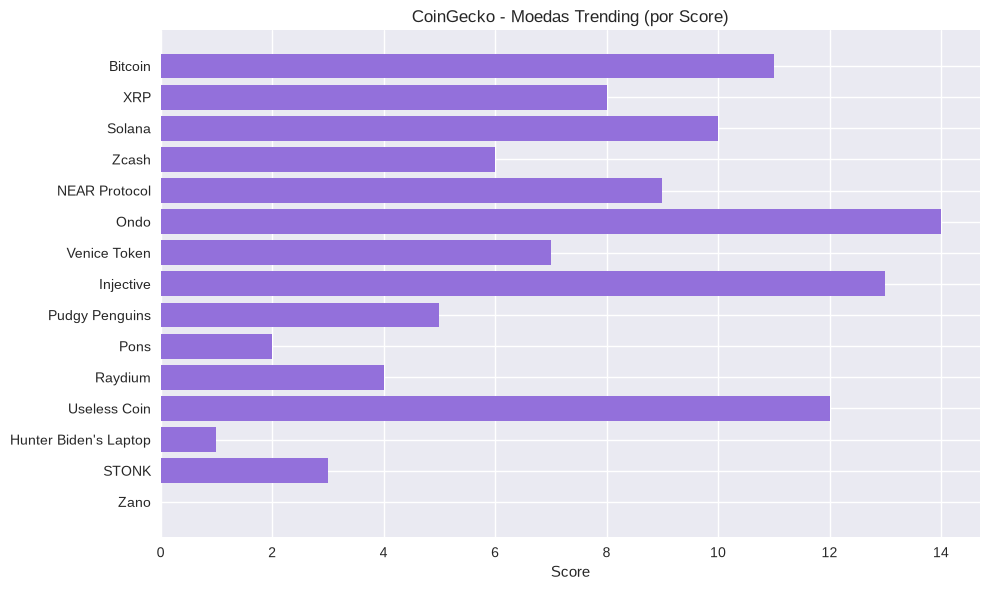

In [41]:
if len(df_trend) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(df_trend['name'], df_trend['score'], color='mediumpurple')
    plt.xlabel('Score')
    plt.title('CoinGecko - Moedas Trending (por Score)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Historico de Jobs ETL

Consulta o historico de execucoes do pipeline registrado no `metadata.job_log`.

In [42]:
query_jobs = """
SELECT * FROM metadata.v_latest_jobs
ORDER BY started_at DESC
LIMIT 20
"""

pd.read_sql(query_jobs, engine)

,id,job_name,source_api,endpoint,status,records_extracted,records_loaded,error_message,started_at,finished_at,duration_seconds
0,59,pipeline_etl_api,coingecko,/coins/markets,success,100,100,None,2026-09-11 12:58:19.643527+00:00,2026-09-11 12:58:25.614755+00:00,5.97
1,31,test,test,test,running,0,0,None,2026-09-10 21:12:50.582670+00:00,NaT,NaN


In [43]:
query_summary = """
SELECT * FROM metadata.v_load_summary
"""

pd.read_sql(query_summary, engine)

,source_api,total_jobs,successful_jobs,failed_jobs,total_extracted,total_loaded,last_run
0,jsonplaceholder,4,3,1,300,300,2026-09-10 20:41:35.299543+00:00
1,coingecko,25,25,0,21806,21806,2026-09-11 12:58:25.614755+00:00


## 8. Fechamento

In [44]:
engine.dispose()
print('Conexao fechada.')

Conexao fechada.
